In [1]:
import utils.data as data
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, RocCurveDisplay
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm

mpl.rcParams["figure.dpi"] = 300

dataset = data.MalwareDataset()
labels = np.array([label for _, label in dataset])
fn_matrix = np.load("fn_matrix.npy")
train_X, test_X, train_y, test_y = train_test_split(fn_matrix, labels)
print(train_X.shape, test_X.shape, train_y.shape, test_y.shape)
device = torch.device("mps")

(8336, 34975)
(2779, 34975)
(8336,)
(2779,)

# SVM

precision    recall  f1-score   support

           0       0.89      0.95      0.92      1340
           1       0.95      0.89      0.92      1439

    accuracy                           0.92      2779
   macro avg       0.92      0.92      0.92      2779
weighted avg       0.92      0.92      0.92      2779

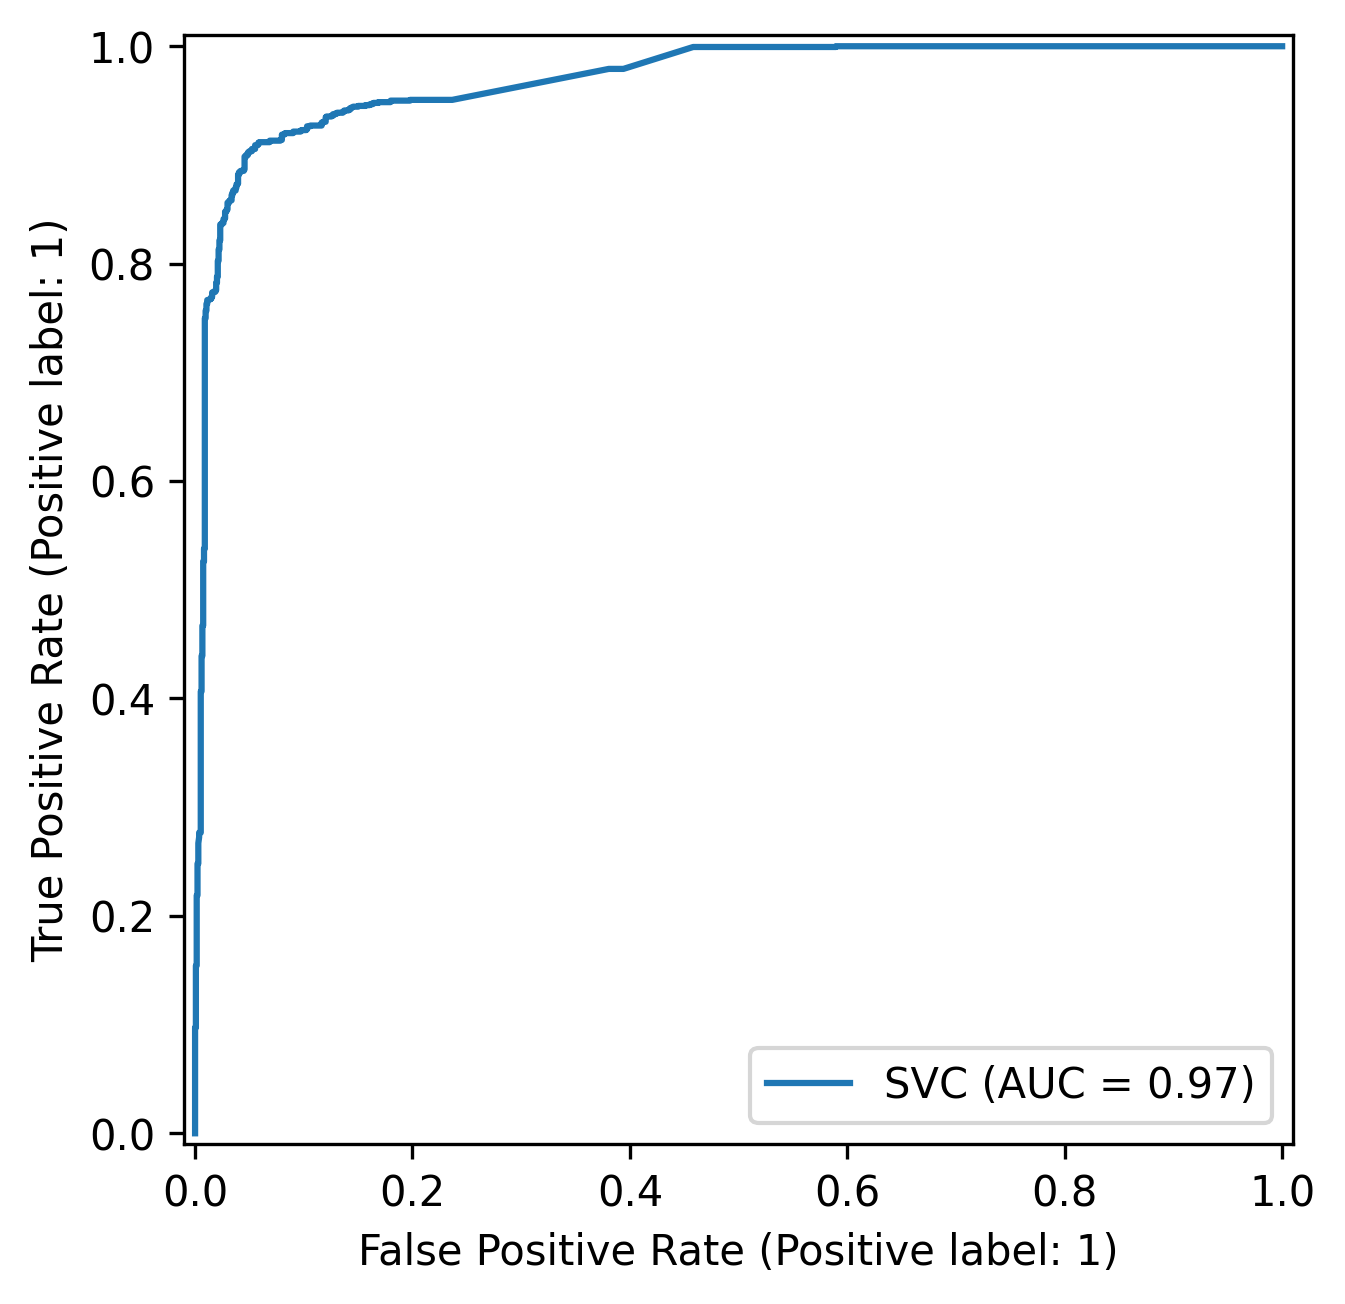

In [4]:
from sklearn import svm

clf = svm.SVC()
clf.fit(train_X, train_y)

y_hat = clf.predict(test_X)

print(classification_report(test_y, y_hat))

RocCurveDisplay.from_estimator(clf, test_X, test_y)

# SGD

precision    recall  f1-score   support

           0       0.93      0.89      0.91      1340
           1       0.90      0.94      0.92      1439

    accuracy                           0.91      2779
   macro avg       0.92      0.91      0.91      2779
weighted avg       0.92      0.91      0.91      2779

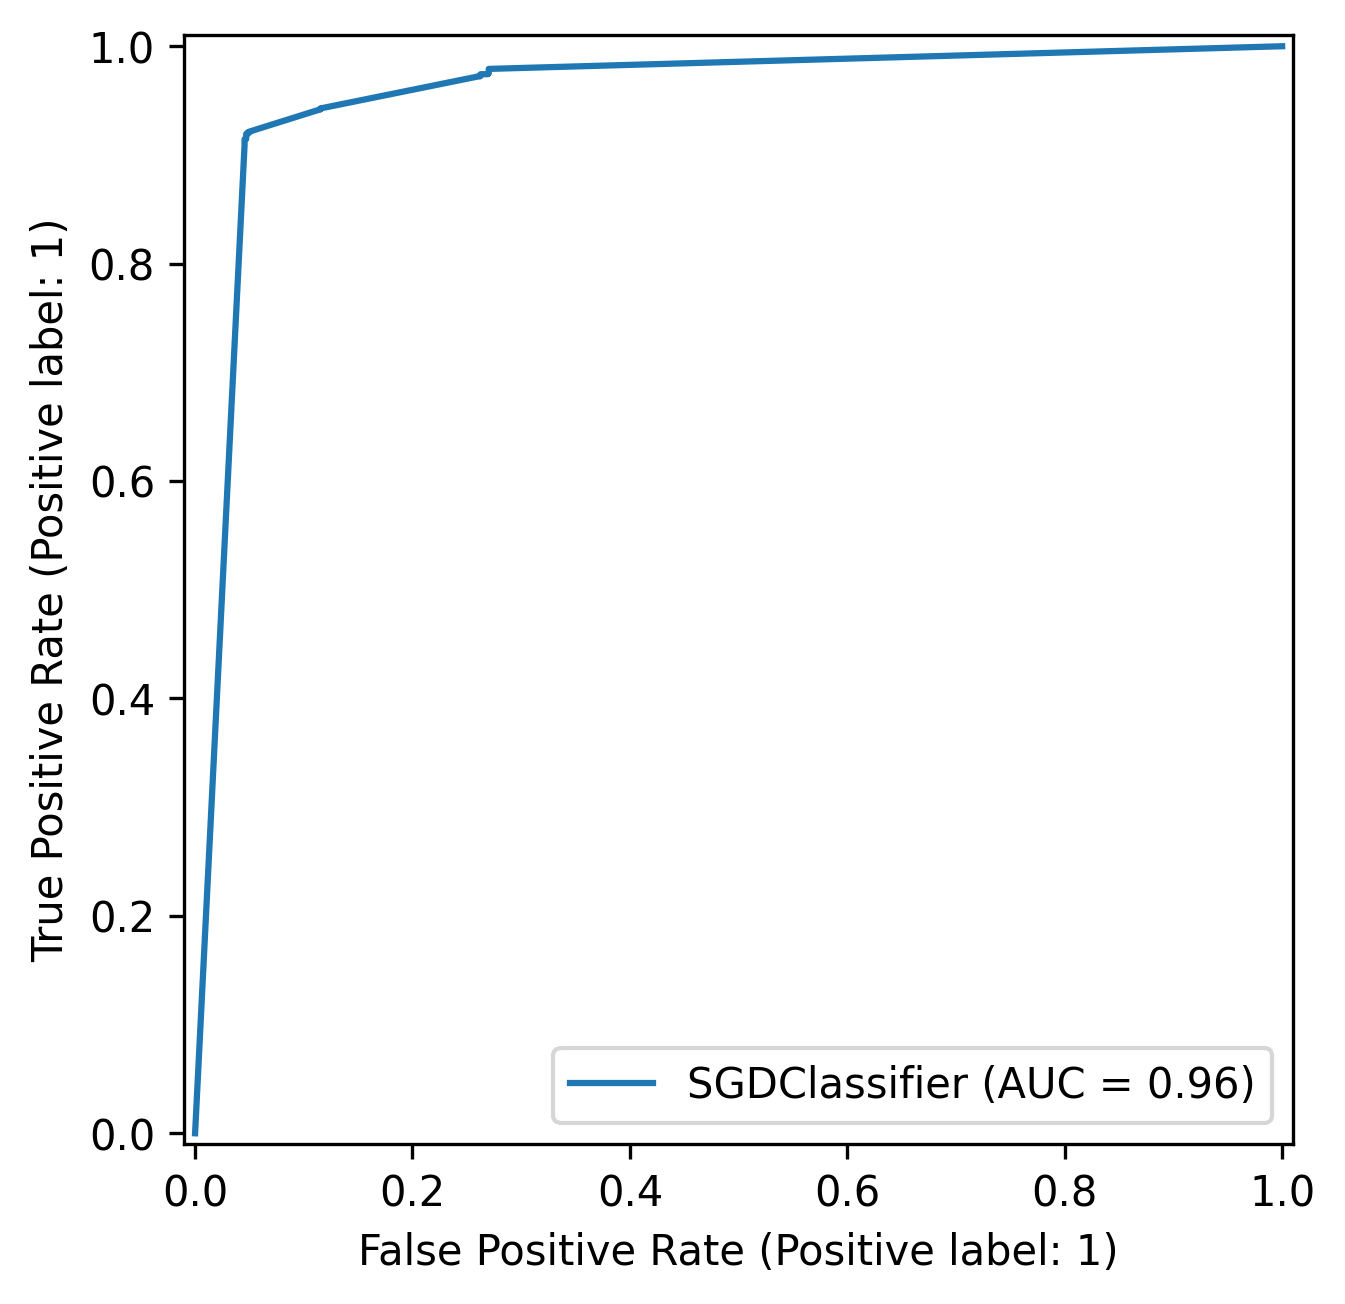

In [5]:
from sklearn.linear_model import SGDClassifier

clf = SGDClassifier(loss="modified_huber")
clf.fit(train_X, train_y)

y_hat = clf.predict(test_X)
print(classification_report(test_y, y_hat))
RocCurveDisplay.from_estimator(clf, test_X, test_y)

# Decision Tree

precision    recall  f1-score   support

           0       0.90      0.97      0.93      1323
           1       0.97      0.90      0.93      1456

    accuracy                           0.93      2779
   macro avg       0.93      0.94      0.93      2779
weighted avg       0.94      0.93      0.93      2779

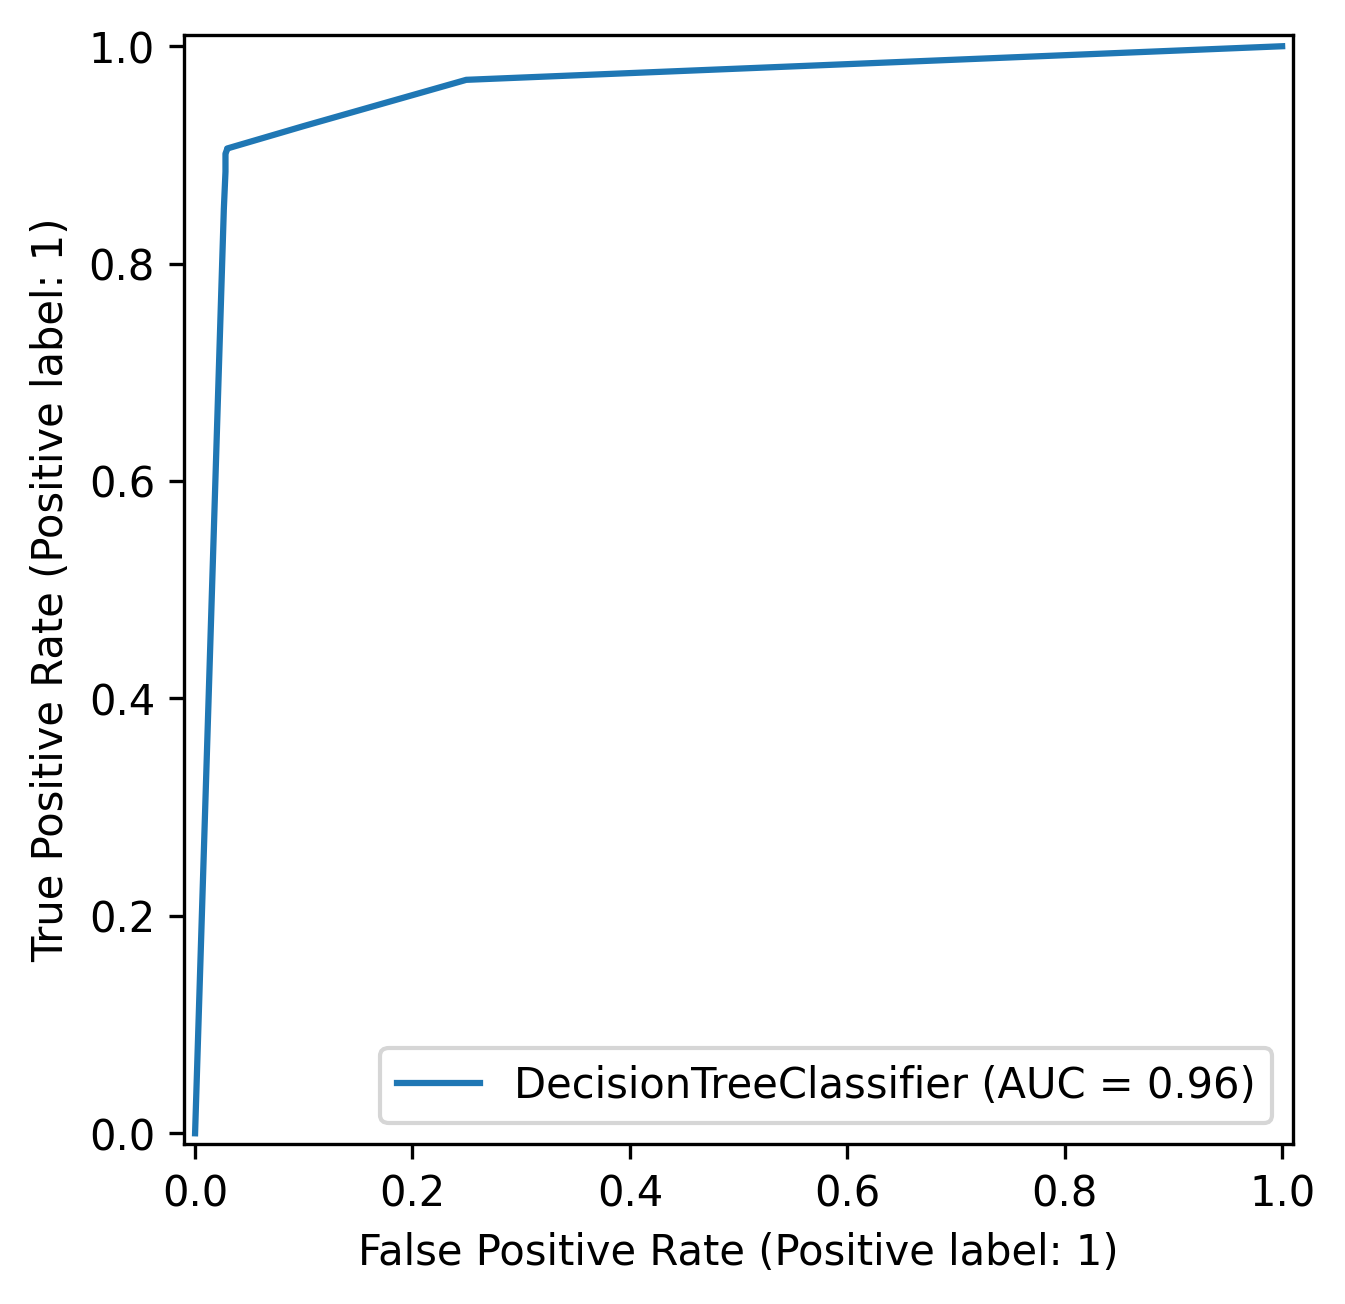

In [2]:
from sklearn import tree

clf = tree.DecisionTreeClassifier()
clf.fit(train_X, train_y)

y_hat = clf.predict(test_X)
print(classification_report(test_y, y_hat))
RocCurveDisplay.from_estimator(clf, test_X, test_y)

In [8]:
from sklearn.tree import plot_tree

fig = plt.figure(dpi=300, figsize=(50, 50))
ax = fig.add_subplot()
plot_tree(clf, ax=ax)
plt.savefig("./dt.png")

In [2]:
class Classifier(nn.Module):
    def __init__(self, in_features: int, layer_spec):
        super(Classifier, self).__init__()

        layer_spec.insert(0, in_features)

        self.model = nn.Sequential(
            *[
                nn.Sequential(
                    nn.Linear(prev_layer, layer), nn.BatchNorm1d(layer), nn.ReLU()
                )
                for prev_layer, layer in zip(layer_spec, layer_spec[1:])
            ]
            + [nn.Sequential(nn.Linear(layer_spec[-1], 2), nn.Sigmoid())]
        )

    def forward(self, x):
        return self.model(x)

In [3]:
train_ds = TensorDataset(
    torch.tensor(train_X, dtype=torch.float32),
    F.one_hot(torch.tensor(train_y), 2).to(torch.float32),
)
test_ds = TensorDataset(
    torch.tensor(test_X, dtype=torch.float32),
    F.one_hot(torch.tensor(test_y), 2).to(torch.float32),
)

In [ ]:
def test(model, dataset, criterion):
    model.eval()
    predicted = []
    actual = []
    test_loss = 0.0

    test_loop = tqdm(dataset, desc=f"Test Epoch {epoch + 1}/{EPOCHS}", leave=False)

    for i, (X, y) in enumerate(test_loop):
        X = X.to(device)
        y = y.to(device)

        with torch.no_grad():
            logits = model(X)

        loss = criterion(logits, y)
        test_loss += loss.item()

        for y_hat, yi in zip(logits, y):
            predicted.append(y_hat.argmax().item())
            actual.append(yi.argmax().item())

        test_loop.set_postfix_str(f"Loss: {test_loss / (i + 1):.2f}")

    model.train()
    return test_loss / len(dataset), classification_report(
        actual, predicted, output_dict=True
    )


EPOCHS = 200
LR = 1e-3
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, BATCH_SIZE)
test_loader = DataLoader(test_ds, BATCH_SIZE)

model = Classifier(fn_matrix.shape[1], [4096, 2048, 1048, 512, 256, 128]).to(device)
criterion = nn.BCEWithLogitsLoss(reduction="sum").to(device)
optim = torch.optim.Adam(model.parameters(), lr=LR)
reports = []
losses = []
test_losses = []

for epoch in range(EPOCHS):
    train_loop = tqdm(
        train_loader, desc=f"Train Epoch {epoch + 1}/{EPOCHS}", leave=False
    )

    for X, y in train_loop:
        X = X.to(device)
        y = y.to(device)

        optim.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        losses.append(loss.item())
        loss.backward()
        optim.step()
        train_loop.set_postfix_str(f"Loss: {loss.item():.2}")

    test_loss, report = test(model, test_loader, criterion)
    reports.append(report)
    test_losses.append(test_loss)

KeyboardInterrupt: 

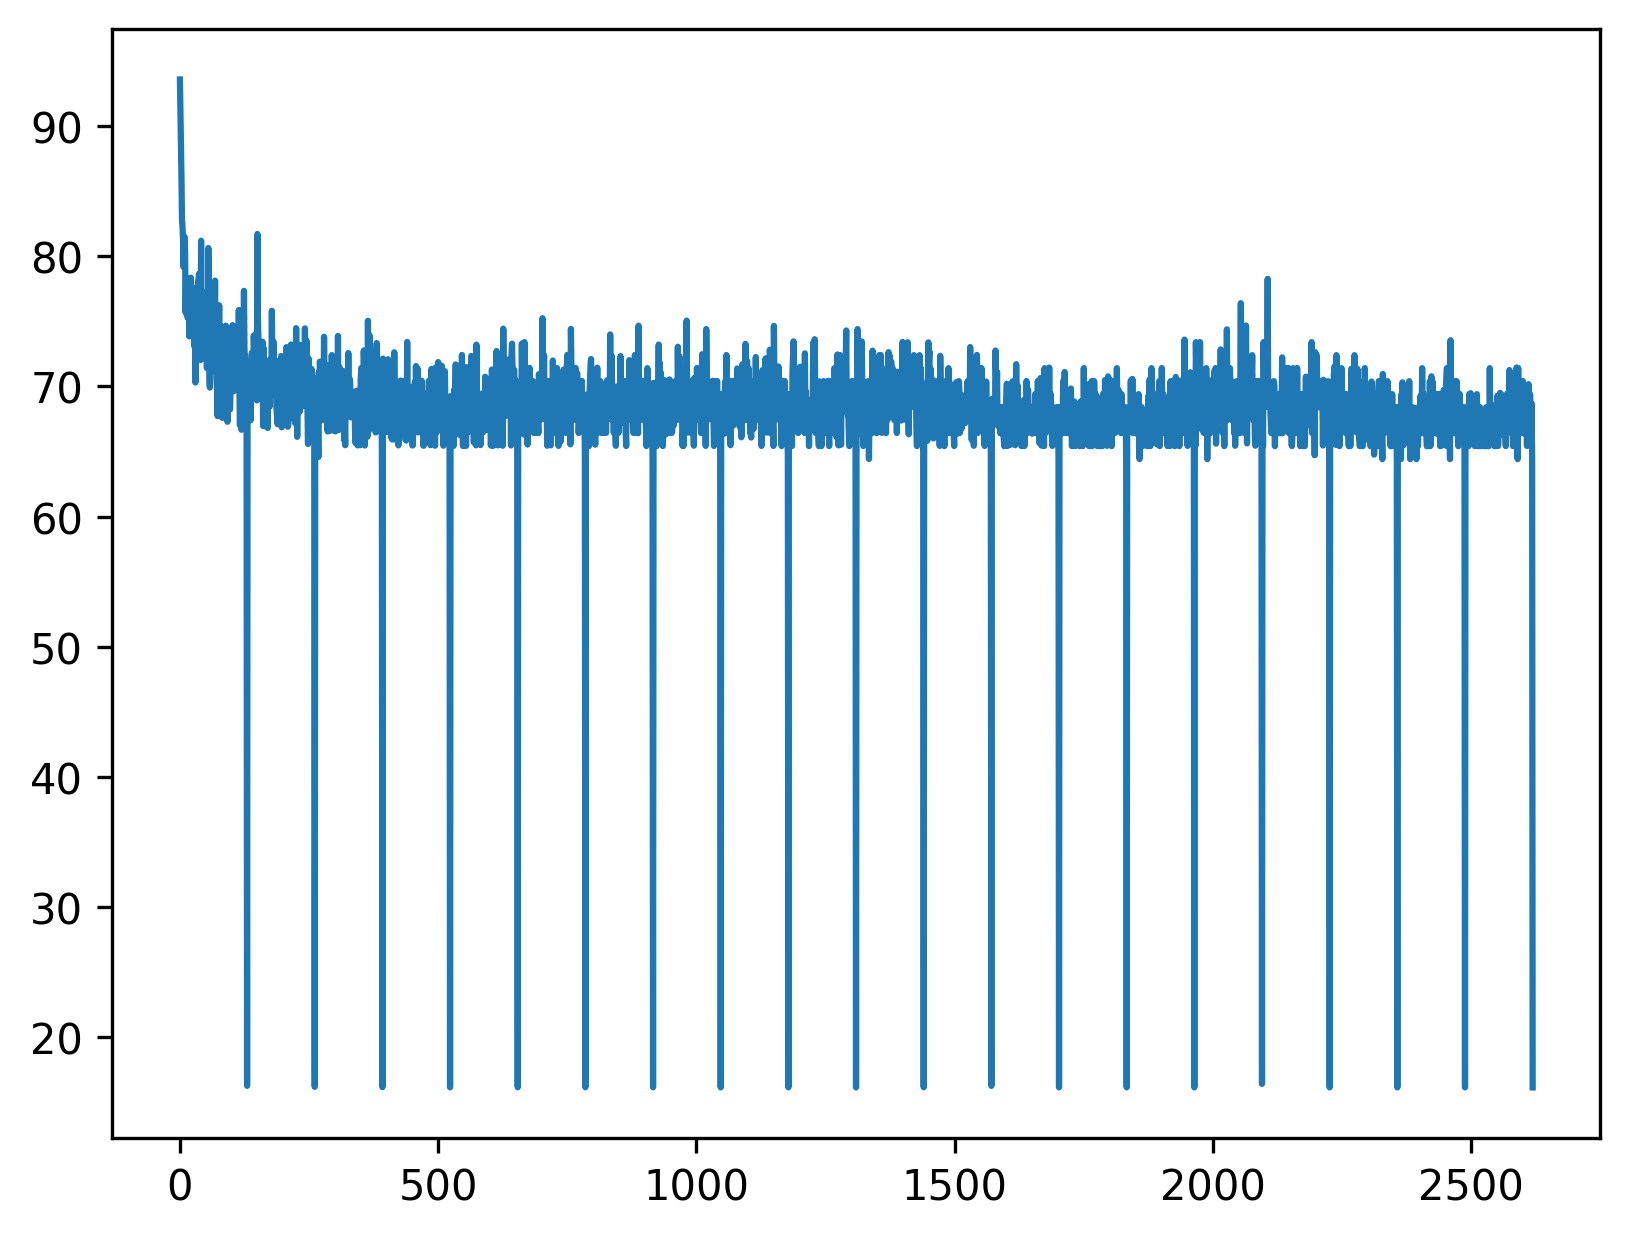

In [6]:
from scipy.ndimage import gaussian_filter

plt.plot(losses)

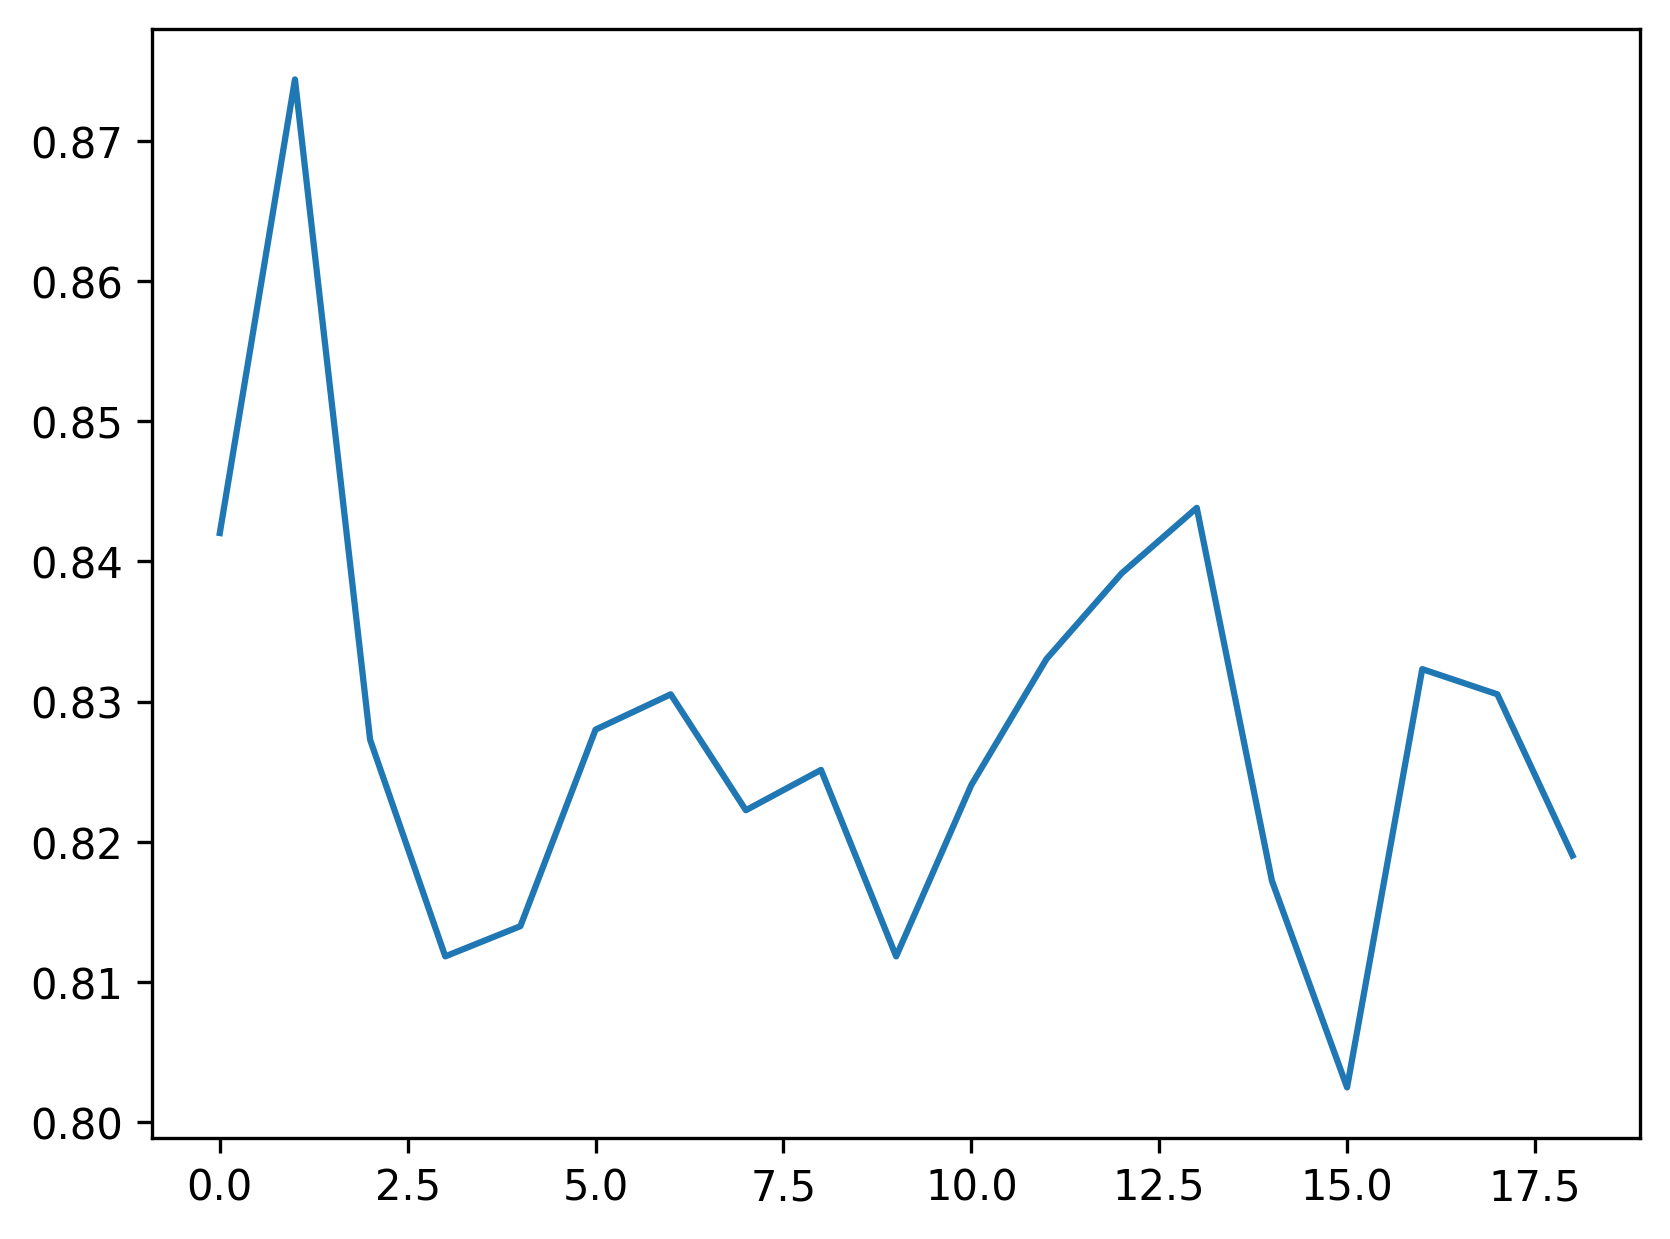

In [8]:
import pandas as pd

plt.plot(pd.DataFrame(reports)["accuracy"].to_numpy())

In [ ]:
train_iter = iter(train_loader)

for i in range(np.argmin(losses[: len(train_loader)])):
    X, y = next(train_iter)

In [36]:
y_hat = model(X.to(device))
torch.tensor([torch.argmax(y_hat, dim=1), y.argmax(dim=1)])

TypeError: only integer tensors of a single element can be converted to an index